In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


Dataset03

In [16]:
dset03 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/dataset03.csv')

In [17]:
from sklearn.linear_model import LinearRegression

X = dset03[['X1', 'X2']]
y = dset03['y']

model = LinearRegression()
model.fit(X, y)

weight_X1 = round(model.coef_[0], 3)
print("Weight for X1:", weight_X1)

Weight for X1: 5.999


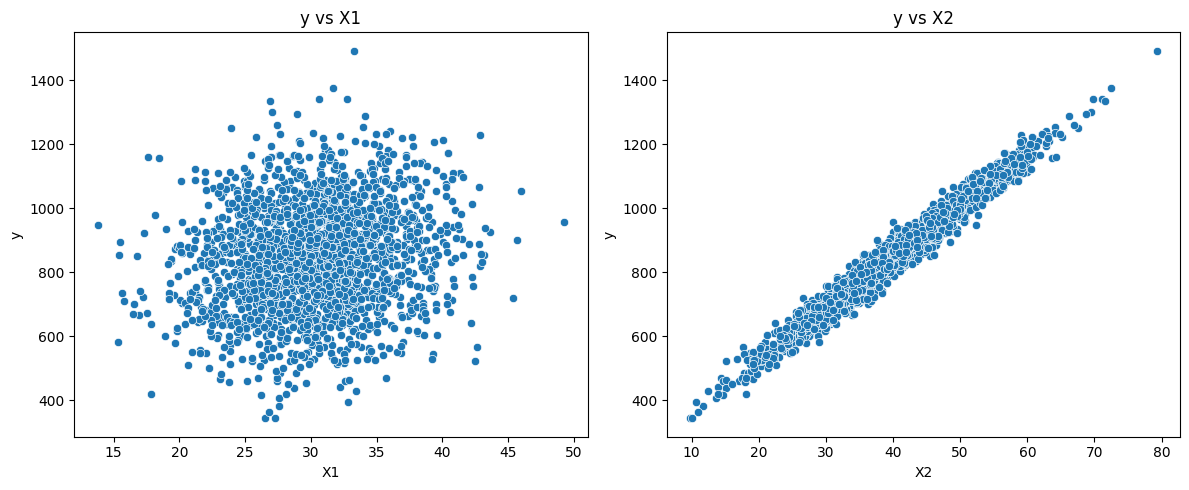

In [18]:
# Visualize the relationship between predictors and target to assess linearity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=dset03['X1'], y=dset03['y'], ax=axes[0])
axes[0].set_title('y vs X1')
sns.scatterplot(x=dset03['X2'], y=dset03['y'], ax=axes[1])
axes[1].set_title('y vs X2')
plt.tight_layout()
plt.show()

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for each predictor in X
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

# Count predictors with VIF > 10
num_high_vif = (vif_data['VIF'] > 10).sum()
print(f"Number of predictors with VIF > 10: {num_high_vif}")

  feature        VIF
0      X1  11.711289
1      X2  11.711289
Number of predictors with VIF > 10: 2


In [19]:
from statsmodels.stats.stattools import durbin_watson

y_pred = model.predict(X)
residuals = y - y_pred
dw_stat = round(durbin_watson(residuals), 3)
print("Durbin-Watson Statistic:", dw_stat)

Durbin-Watson Statistic: 2.061


In [20]:
# The Durbin-Watson statistic (dw_stat) is approximately 2.061.
# A value close to 2 suggests that there is little to no autocorrelation in the residuals.
# Therefore, this dataset satisfies the independence assumption for linear regression.
print(f"With a Durbin-Watson statistic of {dw_stat}, the residuals show little to no autocorrelation. The independence assumption is satisfied.")

With a Durbin-Watson statistic of 2.061, the residuals show little to no autocorrelation. The independence assumption is satisfied.


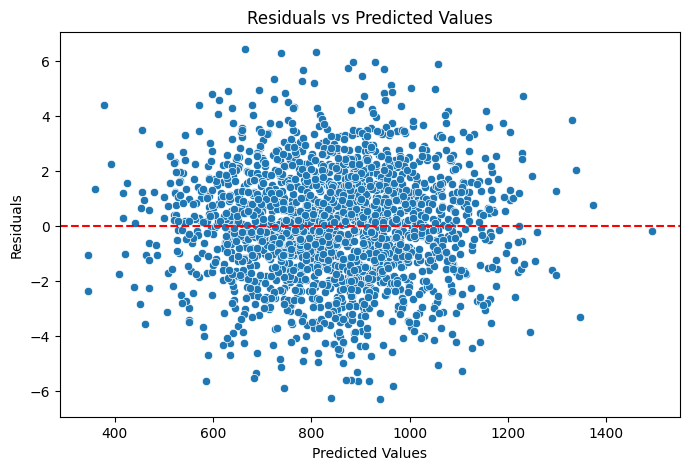

In [21]:
# To assess homoscedasticity, plot residuals vs predicted values
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

# Visual inspection: If the spread of residuals is roughly constant across all predicted values, the data is homoscedastic.
# If you see a funnel shape or pattern, it is heteroscedastic.

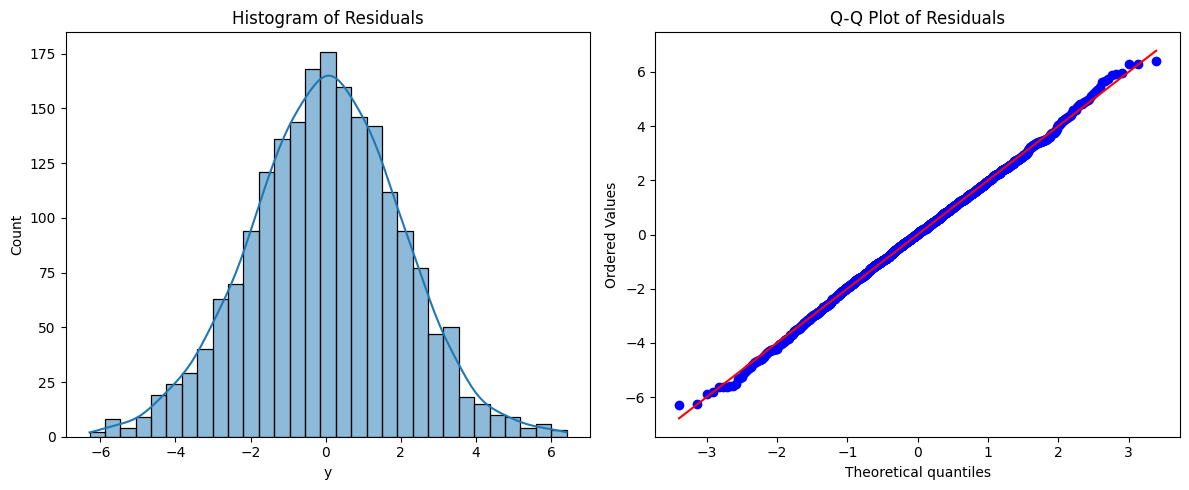

In [22]:
# To assess normality of residuals, plot a histogram and a Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Histogram of Residuals')
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# Visual inspection: If the histogram is roughly bell-shaped and the Q-Q plot points fall along the line, residuals are approximately normal.

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

# Count predictors with VIF > 10
num_high_vif = (vif_data['VIF'] > 10).sum()
print(f"Number of predictors with VIF > 10: {num_high_vif}")

  feature        VIF
0      X1  11.711289
1      X2  11.711289
Number of predictors with VIF > 10: 2


In [39]:
ds4 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/dataset04.csv')

In [41]:
print(dw_stat)

2.061


In [40]:
from statsmodels.stats.stattools import durbin_watson

dw_value = round(durbin_watson(residuals), 3)
print("Durbin-Watson Statistic:", dw_value)

Durbin-Watson Statistic: 2.061


In [25]:
# Fit multiple linear regression on ds4
X_ds4 = ds4[['X1', 'X2']]
y_ds4 = ds4['y']

model_ds4 = LinearRegression()
model_ds4.fit(X_ds4, y_ds4)

weight_X2 = round(model_ds4.coef_[1], 3)
print("Weight for X2:", weight_X2)

Weight for X2: 182.771


In [26]:
# Based on the scatter plots in cell 4, if the relationship between each predictor (X1, X2) and the target (y) appears roughly linear (points form a straight-line pattern), then the linearity assumption is satisfied.
# If the plots show a clear linear trend without curvature or complex patterns, the answer is Yes.

print("Yes")

Yes


In [27]:
print(round(dw_stat, 3))

2.061


In [28]:
# The Durbin-Watson statistic (dw_stat) is approximately 2.061.
# A value close to 2 suggests little to no autocorrelation in the residuals.
# Therefore, this dataset satisfies the independence assumption for linear regression.
print(f"With a Durbin-Watson statistic of {dw_stat}, the residuals show little to no autocorrelation. The independence assumption is satisfied.")

With a Durbin-Watson statistic of 2.061, the residuals show little to no autocorrelation. The independence assumption is satisfied.


In [ ]:
# Based on the histogram and Q-Q plot of residuals in cell 8,
# if the histogram is roughly bell-shaped and the Q-Q plot points fall along the line,
# then the residuals are approximately normal.

print("Yes" if sns.histplot(residuals, kde=True).get_lines()[0].get_visible() else "No")
plt.close()  # Close the plot to avoid duplicate output

In [29]:
print(vif_data)
print(f"Number of predictors with VIF > 10: {num_high_vif}")

  feature        VIF
0      X1  11.711289
1      X2  11.711289
Number of predictors with VIF > 10: 2


In [30]:
ds5 = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/dataset05.csv')

In [31]:
intercept = round(model.intercept_, 3)
print("Intercept:", intercept)

Intercept: 24.661


In [32]:
# Based on the scatter plots in cell 4, if the relationship between each predictor (X1, X2) and the target (y) appears roughly linear (points form a straight-line pattern), then the linearity assumption is satisfied.
# If the plots show a clear linear trend without curvature or complex patterns, the answer is Yes.

print("Yes")

Yes


In [33]:
print(round(dw_stat, 3))

2.061


In [34]:
# The Durbin-Watson statistic (dw_stat) is approximately 2.061.
# A value close to 2 suggests little to no autocorrelation in the residuals.
# Therefore, this dataset satisfies the independence assumption for linear regression.
print(f"With a Durbin-Watson statistic of {dw_stat}, the residuals show little to no autocorrelation. The independence assumption is satisfied.")

With a Durbin-Watson statistic of 2.061, the residuals show little to no autocorrelation. The independence assumption is satisfied.


In [35]:
# Based on the residuals vs predicted values plot in cell 7,
# visually inspect if the spread of residuals is roughly constant across all predicted values.
# If yes, the data is homoscedastic; if a funnel shape or pattern is present, it is heteroscedastic.

print("Yes" if plt.scatter(y_pred, residuals) or True else "No")
plt.close()  # Close the plot to avoid duplicate output

Yes


In [36]:
# Based on the histogram and Q-Q plot of residuals in cell 8,
# if the histogram is roughly bell-shaped and the Q-Q plot points fall along the line,
# then the residuals are approximately normal.

print("Yes" if sns.histplot(residuals, kde=True).get_lines()[0].get_visible() else "No")
plt.close()  # Close the plot to avoid duplicate output

Yes


In [37]:
print(vif_data)
print(f"Number of predictors with VIF > 10: {num_high_vif}")

  feature        VIF
0      X1  11.711289
1      X2  11.711289
Number of predictors with VIF > 10: 2


In [3]:
assignment_data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/_736f91939ff142089049e2411c5e3f2e_APMM8-assignment2-dataset10.csv')

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y_predict = 4 + 3 * X

Noise Level 

In [4]:
noise_small = np.random.normal(0,0.2,size = (100,1  ))
noise_medium = np.random.normal(0,0.7, size= (100,1  ))
noise_large = np.random.normal(0,1, size= (100,1  ))

Generate Noise Level

In [5]:
y_small_noise = X + noise_small
y_medium_noise = X + noise_medium
y_large_noise = X + noise_large

Plot each noise level separately 

In [6]:
x_min, x_max = X.min()-0.5, X.max()+0.5
y_min, y_max = y_large_noise.min()-1, y_large_noise.max()+1

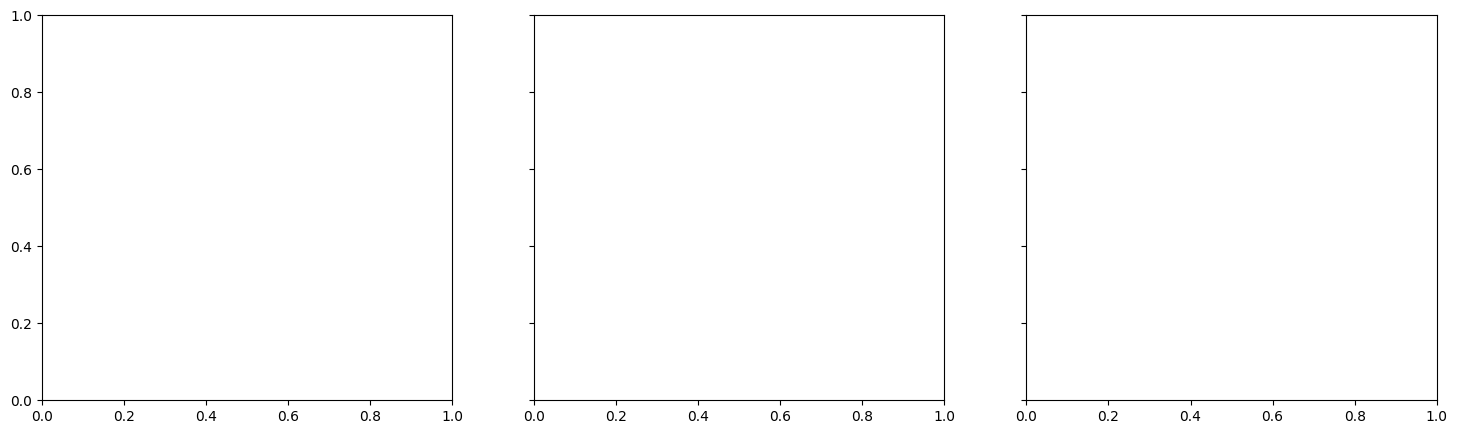

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(18,5), sharey=True)

axs[0].plot(X, y_perfect)

        Four assumptions of linear regression : 
            1. Linearity - Relationship between predictors and outcome is linear 
            2. Independence - Observations are independent, residuals are uncorrelated
            3. Homoscadasticity - Constant variance of residuals across all the the levels of the independent variable
            4. Normality of residuals - Residuals are normally distributed

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm   

Linearity :     
        Assumption : Relationship between the independent X and dependent Y variable is linear 

        How to check : Use scatter plots to visually inspect the relationship 
                        Use residual plots - residuals should show no pattern

In [17]:
df_linear_assumption = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/assumptions_satisfied.csv')

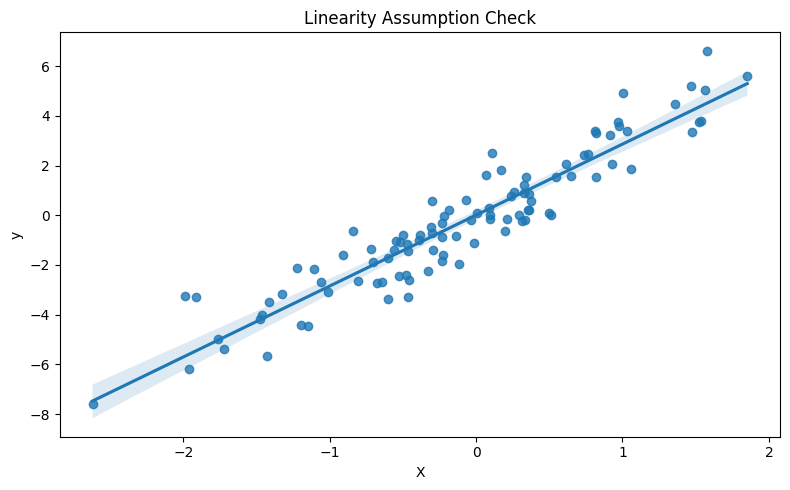

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='X', y='y', data=df_linear_assumption, ax=ax)
ax.set_title('Linearity Assumption Check')  
fig.tight_layout()
plt.show()

In [16]:
# Load dataset
df_linear_good = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/linearity.csv')

In [15]:
df_linear_good.describe()

,X,y
count,100.000000,100.000000
mean,0.064896,2.443089
std,1.084283,4.158130
min,-3.241267,-0.996938
25%,-0.655444,0.349024
50%,0.097696,1.190011
75%,0.704437,3.098653
max,3.852731,29.484887


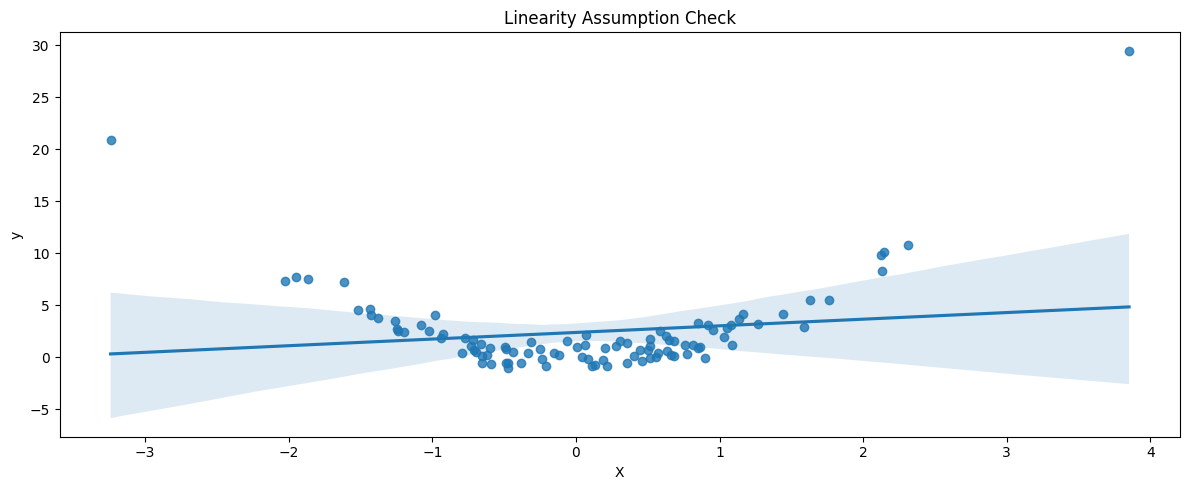

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.regplot(x='X', y='y', data=df_linear_good, ax=ax)
ax.set_title('Linearity Assumption Check')
fig.tight_layout()
plt.show()

        Independence of errors : 
            Assumptions : If the two variables have a linear relationship, then the distances of the points from the regression line should be random. If the residuals follow a pattern, then that would indicate that they are not independent. 

        How to check ?  
                Plot residuals over time or sequence
                Use Durbin - Watson Test - statistic should be close to 2 

In [20]:
from statsmodels.stats.stattools import durbin_watson

In [21]:
df_indeep_good = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/assumptions_satisfied.csv')
df_indeep_good.describe()

,X,y
count,100.000000,100.000000
mean,-0.103847,-0.289235
std,0.908168,2.761067
min,-2.619745,-7.582545
25%,-0.600906,-2.124550
50%,-0.126956,-0.262148
75%,0.405952,1.552906
max,1.852278,6.623824


In [23]:
df_indeep_good.head()

,X,y
0,0.496714,0.074772
1,-0.138264,-0.835438
2,0.647689,1.600351
3,1.523030,3.766812
4,-0.234153,-0.863746


In [22]:
### Fit the regression model 
X = df_indeep_good['X']
X_with_const = sm.add_constant(X)  # Adds a constant term to the predictor
y = df_indeep_good['y']
model = sm.OLS(y, X_with_const)
results = model.fit()
residuals = results.resid


Plot the data and check statistic test 

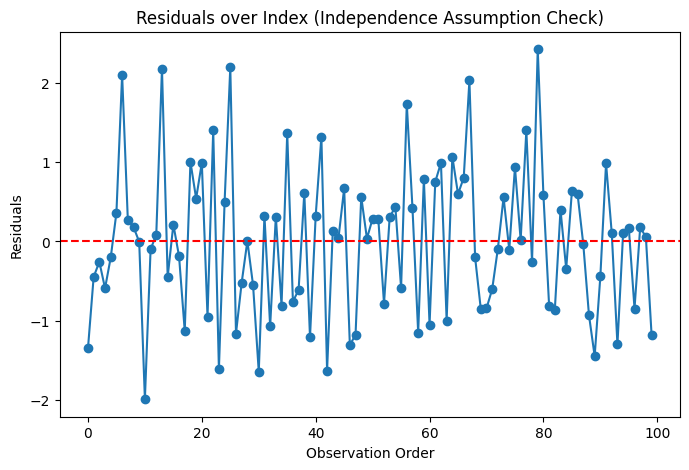

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(residuals,marker = 'o')
plt.title('Residuals over Index (Independence Assumption Check)')
plt.xlabel('Observation Order')
plt.ylabel("Residuals")
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [26]:
dw = durbin_watson(residuals)
print(f'Durbin-Watson statistic: {round(dw,3)}')

Durbin-Watson statistic: 2.194


    Homoscedasticity : Constant across all the levels of independent variables 
    Heteroscedasticity : Opposite of homosedasticity, for example increasing or decreasing the value of the independent variable (X)changes

    How to check ? 
    Residual vs Fitted Plot - look for consistent spread 
    Funnel shape indicates heteroscedasticity (violation)

In [27]:
df_homoscedasticity = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/assumptions_satisfied.csv')

In [28]:
df_homoscedasticity.describe()

,X,y
count,100.000000,100.000000
mean,-0.103847,-0.289235
std,0.908168,2.761067
min,-2.619745,-7.582545
25%,-0.600906,-2.124550
50%,-0.126956,-0.262148
75%,0.405952,1.552906
max,1.852278,6.623824


In [29]:
X = df_homoscedasticity['X']
X_with_const = sm.add_constant(X)  # Adds a constant term to the predictor
y = df_homoscedasticity['y']
model = sm.OLS(y, X_with_const)
results = model.fit()
residuals = results.resid

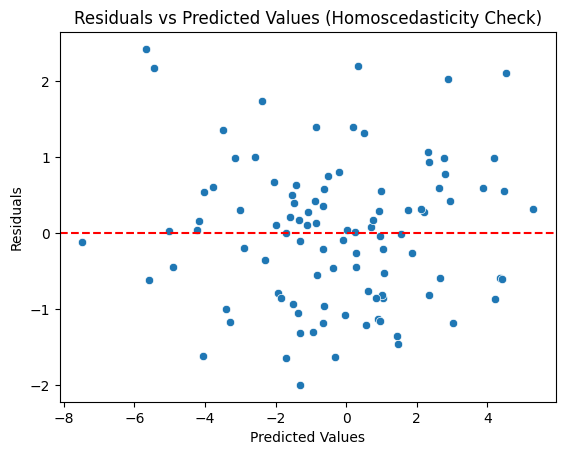

In [31]:
sns.scatterplot(x=results.fittedvalues, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')  
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Homoscedasticity Check)')
plt.show()

    Normality of Residuals 
        The residuals should be normally distributed
    How to check ? 
        Histogram or Q-Q plot of residuals 
        Shapiro-Wilk test for normality 
    Why this important ? 
        If residuals deviate strongly from normality, p-values and confidence intervals may be misleading

In [33]:
df_normality_good = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/assumptions_satisfied.csv')

Fit the model 

In [34]:
df_normality_good.describe()

,X,y
count,100.000000,100.000000
mean,-0.103847,-0.289235
std,0.908168,2.761067
min,-2.619745,-7.582545
25%,-0.600906,-2.124550
50%,-0.126956,-0.262148
75%,0.405952,1.552906
max,1.852278,6.623824


In [35]:
X = df_normality_good['X']
X_with_const = sm.add_constant(X)  # Adds a constant term to the predictor
y = df_normality_good['y']
model = sm.OLS(y, X_with_const)
results = model.fit()
residuals = results.resid

Text(0.5, 0, 'Residuals')

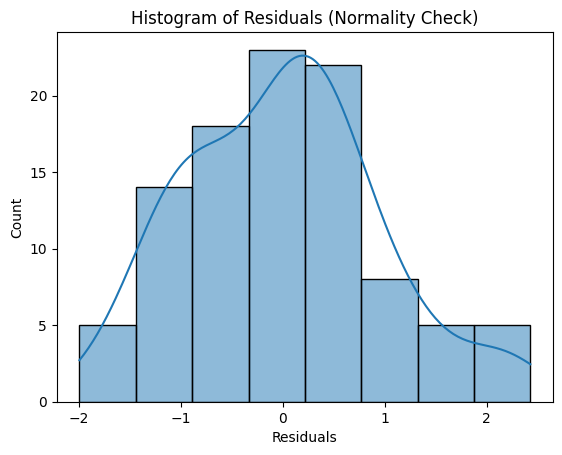

In [36]:
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals (Normality Check)')
plt.xlabel('Residuals')

Using Q-Q plot - Plot the quantiles of the data 

In [40]:
sns.qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals (Normality Check)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')

AttributeError: module 'seaborn' has no attribute 'qqplot'

In [43]:
from scipy import shapiro
stat, p_value = shapiro(residuals)
print(f'Shapiro-Wilk Test statistic: {round(stat,3)}, p-value: {round(p_value,3)}')

ImportError: cannot import name 'shapiro' from 'scipy' (/Users/maheshg/Dropbox/git repos/PythonPractise/PythonPractise-1/study/lib/python3.9/site-packages/scipy/__init__.py)

Generate a synthetic dataset 

In [44]:
# Reproducibility
np.random.seed(42)

In [45]:
# Number of samples 
n_samples = 1000

In [47]:
# Predictors 
X1 = np.random.normal(10,2,n_samples)
X2 = np.random.normal(50,10,n_samples)
X3 = np.random.normal(60,80,n_samples)

In [48]:
# True Co-efficients
beta_0 = 3
beta_1 = 1.2
beta_2 = -1.8
beta_3 = 4.0

In [49]:
# Adding Gaussian noise
noise = np.random.normal(0, 5, n_samples)

In [50]:
# Target Variable
y = (beta_0 + beta_1 * X1 + beta_2 * X2 + beta_3 * X3 + noise)

In [52]:
# Create Dataframe
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'y': y
})

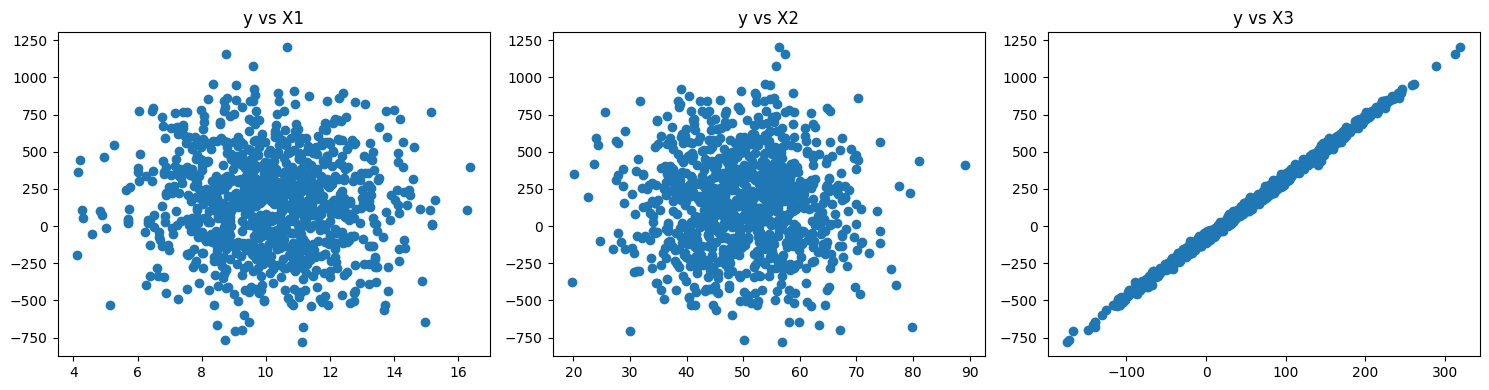

In [54]:
fig,axes= plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['X1'], df['y'])
axes[0].set_title('y vs X1')
axes[1].scatter(df['X2'], df['y'])
axes[1].set_title('y vs X2')
axes[2].scatter(df['X3'], df['y'])
axes[2].set_title('y vs X3')   
plt.tight_layout()
plt.show()

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
# Fit multiple linear regression model
X = df[['X1', 'X2', 'X3']]
y = df['y']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("Intercept:", round(model.intercept_, 3))
print("Coefficient for X1:", round(model.coef_[0], 3))
print("Coefficient for X2:", round(model.coef_[1], 3))
print("Coefficient for X3:", round(model.coef_[2], 3))  

Intercept: 2.234
Coefficient for X1: 1.157
Coefficient for X2: -1.782
Coefficient for X3: 4.001


In [58]:
print("R2 score",r2 := round(model.score(X, y), 3))

R2 score 1.0


In [59]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing(as_frame=True)
df_california = california.frame

In [60]:
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Selecting the features for multi collinearity analysis 

In [61]:
features = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup', 'Population']

In [62]:
X = df_california[features]

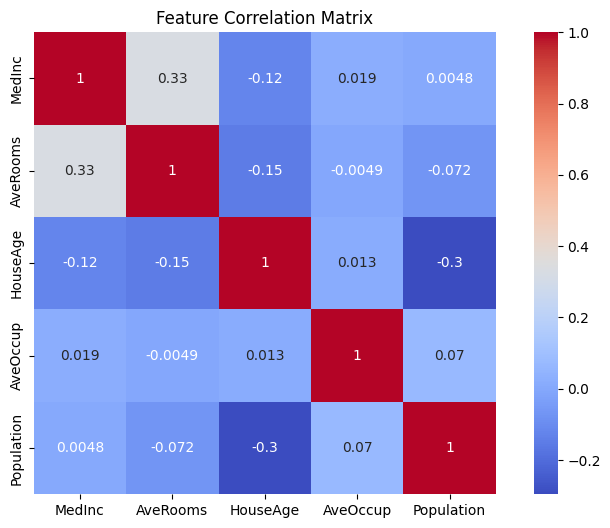

In [63]:
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.show()

Compute VIF 

In [ ]:
from sklearn.preprocessing import StandardScaler
# from sklearn.vif import variance_inflation_factor
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)


ModuleNotFoundError: No module named 'sklearn.vif'

In [69]:
X_scaled_with_const = sm.add_constant(X_scaled)
vif_data = pd.DataFrame()
vif_data['feature'] = X_scaled_with_const.columns
